#### EDA (Exploratory Data Analysis)

1. Load datasets
2. Clean data (missing values,duplicates,types)
3. Treat outliers
4. Univariate and bivariate and multivariate analysis
5. insights

##### Outlier- a data point that is significantly different from other observations in a dataset.

How outliers will come---?
1. Measurement errors
2. Data entry mistakes

Why they are important---?
1. They can be errors
2. They effect the data analysis

How to identify the outliers....?
1. Statistical methods

---> Interquartile Range (IQR)

---> Z-Score

2. Visualization Techniques
---> Box Plots

---> Scatter Plots

---> Histograms


Univariate analysis--a method that analyzes a single variable to describe its characteristics and finding patterns and summarize the data.

It involves only one variable.
 
Bi variate analysis-it will give relationship between 2 variables.It helps to find if there is any co-relation ,association or connection between the 2 variables 

It involves 2 variables (x & y)

Multivariate analysis-To understand how multiple factors interact and influence with each other

It involves more than 2  

Example-

How our age,income,and education level together influence the purchasing behaviour.

### ETL

## EDA : <Dataset>

1. Load &overview

2. Cleaning (missing,dupes,dtypes)

3. Uni , Bi & multi analysis

4. Outlier -IQR

5. Feature Engineering 

6. Key Insights

Feature Engineering - " F.E is the process of turning raw data into useful features" that helps to improve the performance of machine learning models.

1. Load libraries and dataset

In [1]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the coffee dataset from seaborn 
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\earthquake_data_tsunami.csv")
df.head()
df.tail()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
777,7.7,0,8,912,427,0.0,0.0,60.0,13.0490,-88.660,2001,1,0
778,6.9,5,7,745,0,0.0,0.0,36.4,56.7744,-153.281,2001,1,0
779,7.1,0,7,776,372,0.0,0.0,103.0,-14.9280,167.170,2001,1,0
780,6.8,0,5,711,64,0.0,0.0,33.0,6.6310,126.899,2001,1,0
781,7.5,0,7,865,324,0.0,0.0,33.0,6.8980,126.579,2001,1,0


In [3]:
#Basic information and overview of the dataset 
print("Shape of the dataset:",df.shape)
print("\n Info about the dataset ;\n")
df.info()
#Summary Statistics 
df.describe(include='all')

Shape of the dataset: (782, 13)

 Info about the dataset ;

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [4]:
#Missing values analysis 

missing=pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/ len(df)) * 100
})

missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
magnitude,0,0.0
cdi,0,0.0
mmi,0,0.0
sig,0,0.0
nst,0,0.0
dmin,0,0.0
gap,0,0.0
depth,0,0.0
latitude,0,0.0
longitude,0,0.0


In [5]:
# 4. Handling missing values


# Fill numeric missing values with the mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop 'deck' column only if it exists (safe check)
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Check remaining missing values
missing_total = df.isnull().sum().sum()
print("✅ Total missing values after cleaning:", missing_total)



✅ Total missing values after cleaning: 0


Insight:We filled important columns and removed highly missing ones.
This keeps maximum information while making the dataset clean.

In [6]:
#Duplicates and data type check

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df.drop_duplicates(inplace=True)

# Verify again
print("Duplicates after removal:", df.duplicated().sum())



Number of duplicate rows: 0
Duplicates after removal: 0


Numeric Columns: ['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami']

Summary Statistics for Numeric Features:
        magnitude         cdi         mmi          sig         nst  \
count  782.000000  782.000000  782.000000   782.000000  782.000000   
mean     6.941125    4.333760    5.964194   870.108696  230.250639   
std      0.445514    3.169939    1.462724   322.465367  250.188177   
min      6.500000    0.000000    1.000000   650.000000    0.000000   
25%      6.600000    0.000000    5.000000   691.000000    0.000000   
50%      6.800000    5.000000    6.000000   754.000000  140.000000   
75%      7.100000    7.000000    7.000000   909.750000  445.000000   
max      9.100000    9.000000    9.000000  2910.000000  934.000000   

             dmin         gap       depth    latitude   longitude  \
count  782.000000  782.000000  782.000000  782.000000  782.000000   
mean     1.325757   25.038990   75.883199    3.538100

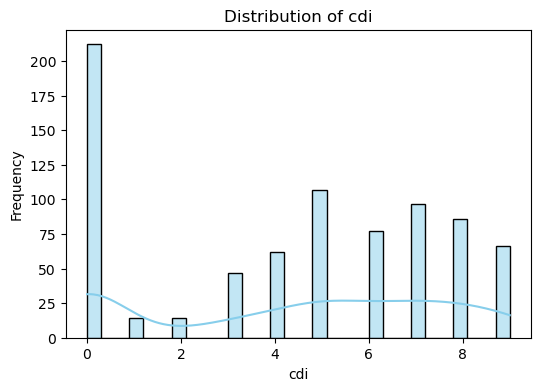

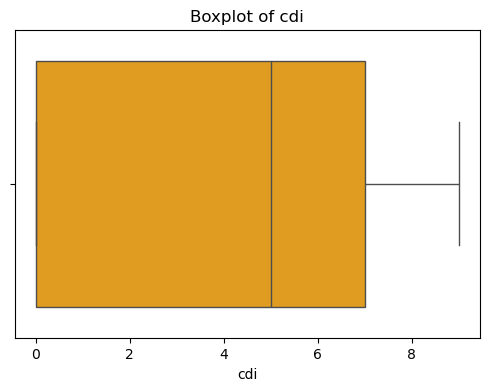

In [7]:
# 6.Univariate analysis -Numerical Features 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric Columns:", num_cols.tolist())

# Summary statistics
print("\nSummary Statistics for Numeric Features:")
print(df[num_cols].describe())

# Plot histograms for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.histplot(df[col], bins=30, kde=True, color='skyblue')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

# Plot boxplots for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[col], color='orange')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)
plt.show()

Categorical Columns: []


C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_3796\3985202358.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')


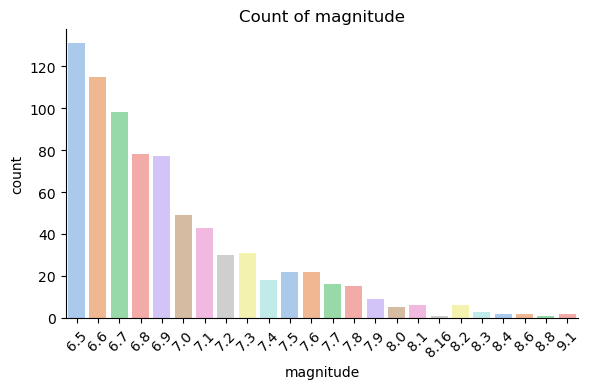

In [8]:
# Univariate Analysis - Categorical Features
# Convert all object columns to category type
df[ df.select_dtypes(include=['object']).columns ] = df.select_dtypes(include=['object']).astype('category')

# Identify categorical columns
cat_cols = df.select_dtypes(include='category').columns
print("Categorical Columns:", cat_cols.tolist())

# Plot count plots for each categorical feature
col=num_cols[0]
sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')
plt.title(f"Count of {col}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_3796\1904815677.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='magnitude', y='Year', data=df, palette='Set2')


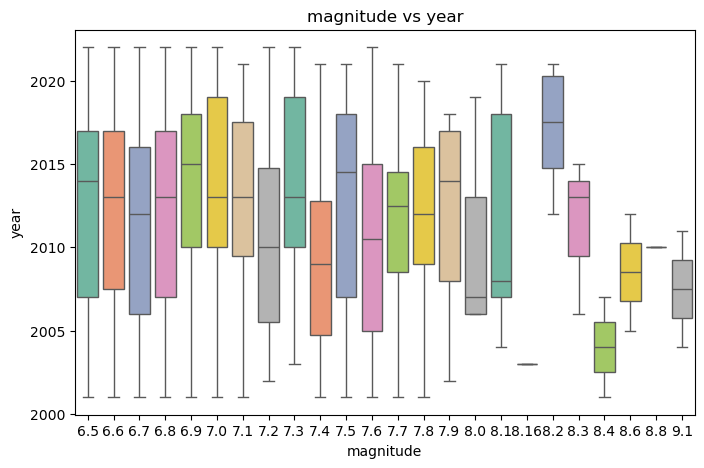

In [9]:
# Bivariate analysis - Numerical vs categorical

plt.figure(figsize=(8,5))
sns.boxplot(x='magnitude', y='Year', data=df, palette='Set2')
plt.title("magnitude vs year")
plt.xlabel("magnitude")
plt.ylabel("year")
plt.show()

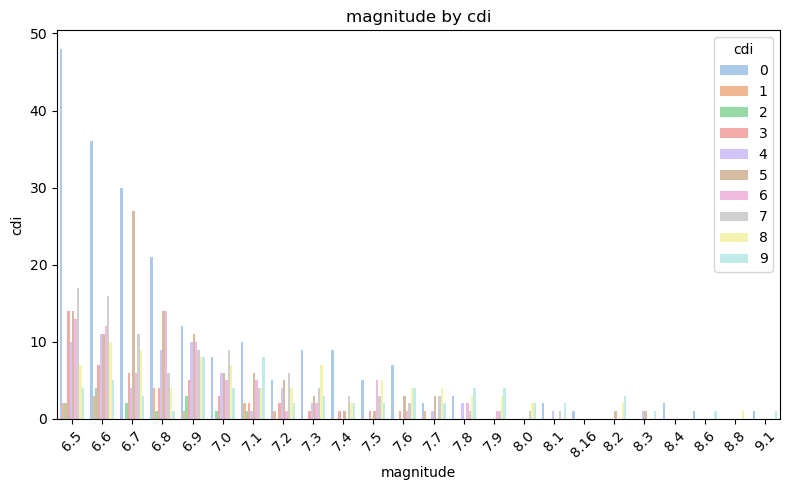

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='magnitude', hue='cdi', data=df, palette='pastel')
plt.title("magnitude by cdi")
plt.xlabel("magnitude")
plt.ylabel("cdi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Numeric columns used for correlation (first 5 columns): ['magnitude', 'cdi', 'mmi', 'sig', 'nst']


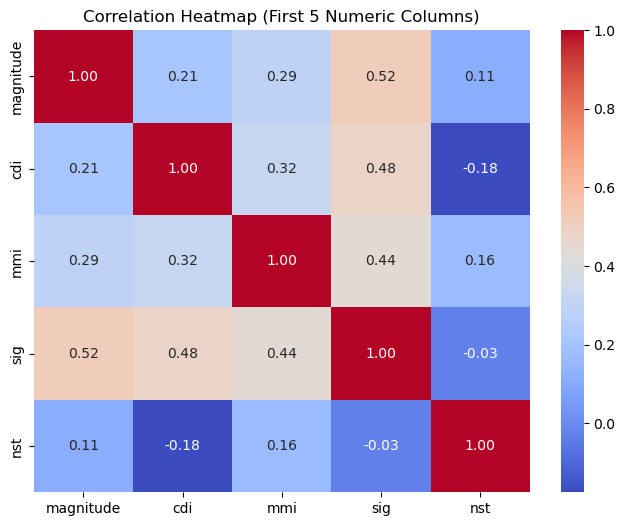

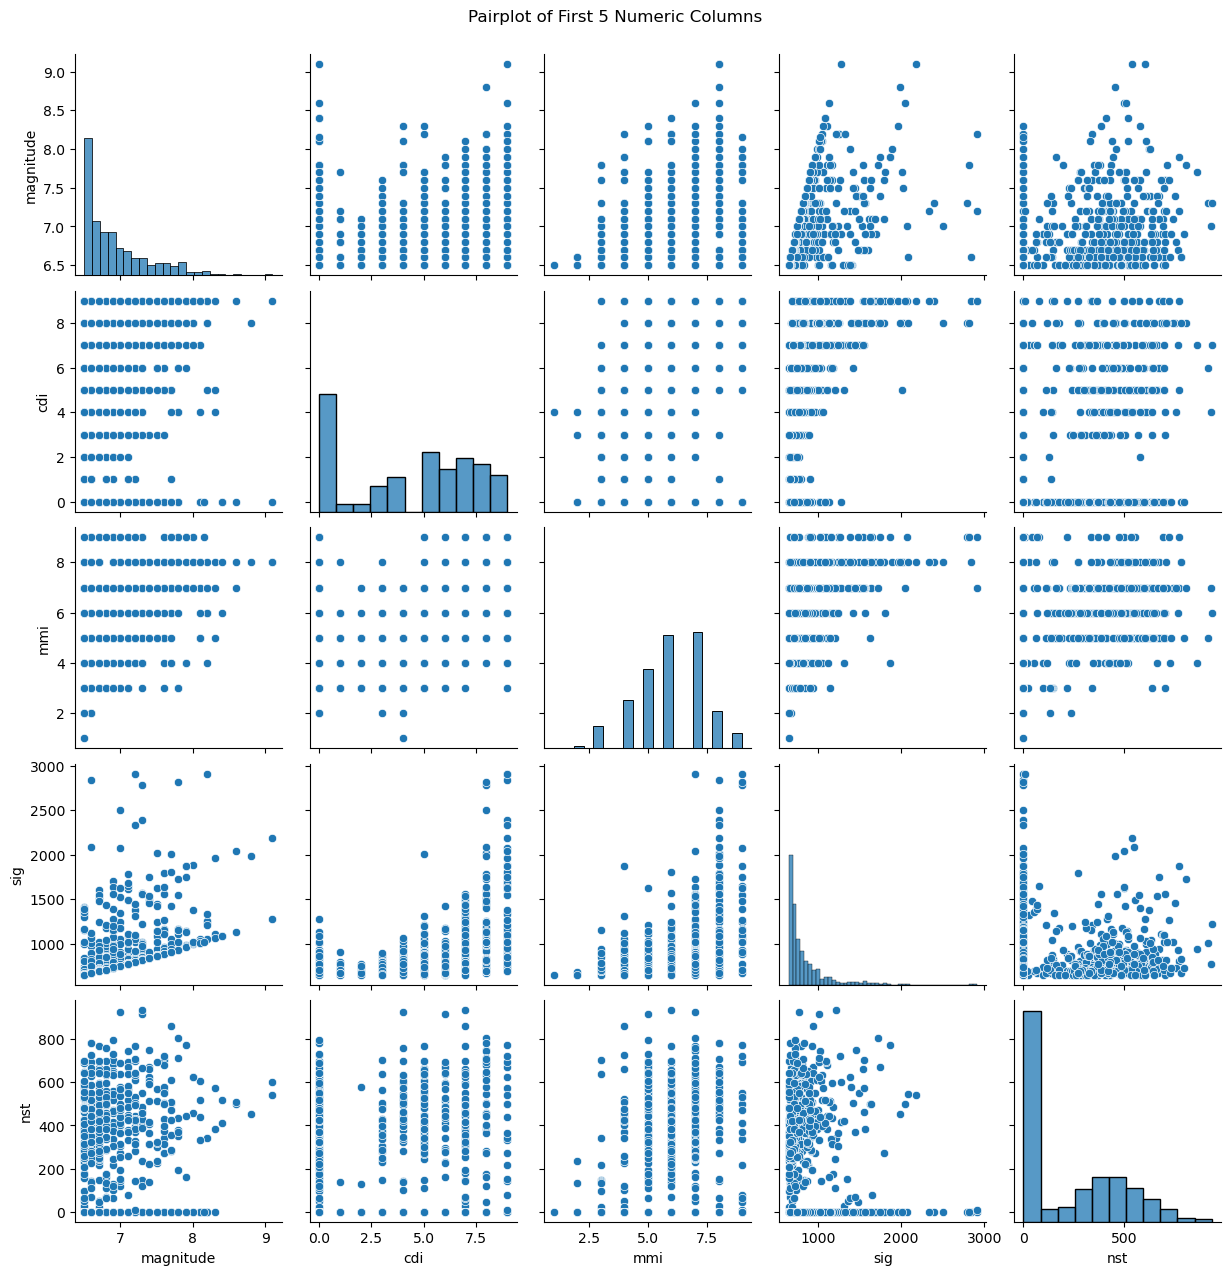

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Take only the first 5 numeric columns
num_cols_subset = num_cols[:5]
print("Numeric columns used for correlation (first 5 columns):", num_cols_subset.tolist())

# Correlation heatmap
corr = df[num_cols_subset].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (First 5 Numeric Columns)")
plt.show()

# Pairplot for numeric features
sns.pairplot(df[num_cols_subset])
plt.suptitle("Pairplot of First 5 Numeric Columns", y=1.02)
plt.show()

### Insights -

1. Magnitude is reported to be 8.

2. 1 indicates highest in correlation.

Number of outliers in cdi: 0


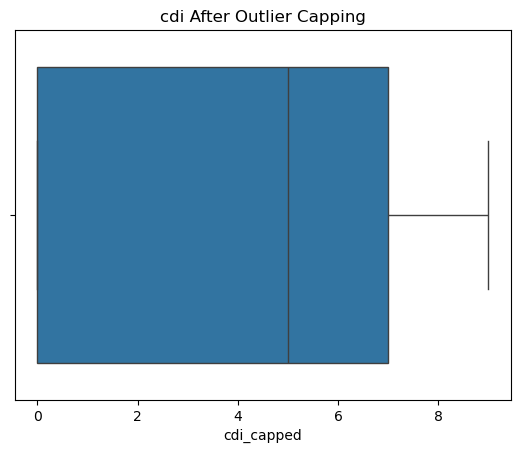

In [15]:
# Outlier Deletion using IQR
Q1 = df['cdi'].quantile(0.25)
Q3 = df['cdi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['cdi'] < lower) | (df['cdi'] > upper)]
print("Number of outliers in cdi:", len(outliers))

# Capping outliers
df['cdi_capped'] = df['cdi'].clip(lower, upper)
sns.boxplot(x=df['cdi_capped'])
plt.title("cdi After Outlier Capping")
plt.show()


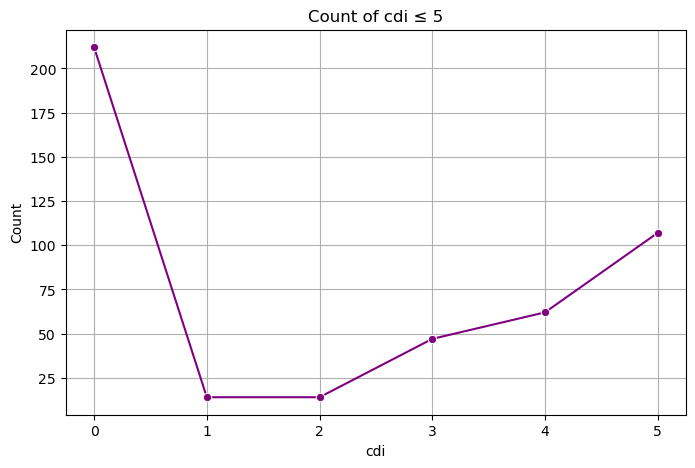

In [16]:
df_under_20 = df[df['cdi'] <= 5]

# Count occurrences of each age
age_counts = df_under_20['cdi'].value_counts().sort_index().reset_index()
age_counts.columns = ['cdi', 'Count']

# Line plot
plt.figure(figsize=(8,5))
sns.lineplot(x='cdi', y='Count', data=age_counts, marker='o', color='purple')
plt.title("Count of cdi ≤ 5")
plt.xlabel("cdi")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [17]:
df.to_csv("earthquake_data_tsunami.csv", index=False)
print("\n✅ Cleaned earthquake data saved as earthquake_data_tsunami.csv")


✅ Cleaned earthquake data saved as earthquake_data_tsunami.csv


In [18]:
import os
print(os.getcwd())

c:\Users\Sriram reddy\OneDrive\Desktop\tekworks\eda assignment
